In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from sklearn.exceptions import ConvergenceWarning, InconsistentVersionWarning
from sklearn.tree import DecisionTreeClassifier

import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix,
    balanced_accuracy_score, cohen_kappa_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

# Test (First Stage)

As it is explained in the documentation submitted, we firstly made the error to test the models on balanced data so all the results bellow cannot be taken into account to take decisions. The correct evaluation is performed in the second section of this notebook (Testing Second Stage)

In [ ]:
TEST_DATA_DIR = '../data/splits/test_final.csv'
test_df = pd.read_csv(TEST_DATA_DIR)

test_df.head(5)

,Elevation,Horizontal_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_Noon,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area3,Wilderness_Area4,Soil_Type2,Soil_Type4,...,Soil_Type12,Soil_Type22,Soil_Type23,Soil_Type38,Soil_Type39,Euclidean_Distance_To_Hydrology,Distance_To_Hydrology_To_Roadways_Ratio,Total_Distance,Aspect_North_South,Cover_Type
0,1.905040e+12,26.616358,17.027224,7.286826e+09,2446,1,0,0,0,0,...,0,0,0,0,0,26.894885,2.838889,38.860450,0.838671,1
1,2.467422e+12,16.576336,44.178571,5.878612e+09,362,0,1,0,0,0,...,0,0,0,0,0,16.999327,1.074519,34.703713,0.829038,0
2,1.214855e+12,7.970902,38.237365,6.986146e+09,335,0,0,1,0,0,...,0,0,0,0,0,8.294834,1.025510,30.800479,0.939693,5
3,1.381086e+12,29.238079,30.362725,1.242193e+10,541,0,0,1,0,0,...,0,0,0,0,0,30.076138,1.594118,31.394317,0.069756,2
4,9.734690e+11,26.348537,25.452623,9.876423e+09,1041,0,0,1,0,0,...,0,0,0,0,0,26.717475,1.720000,32.665238,0.258819,5


In [9]:
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

In [10]:
X_test = test_df.drop('Cover_Type', axis=1)
y_test = test_df['Cover_Type']

mapped_y = y_test.map(covertype_class)
print(mapped_y.value_counts())

Cover_Type
Cottonwood/Willow    550
Ponderosa Pine       550
Douglas-fir          550
Spruce/Fir           549
Aspen                549
Lodgepole Pine       549
Name: count, dtype: int64


## Model Comparison

- El modelo de bagging no tiene para el out of bag evaluation
- No estan subidos todos los Best Hyperparameters

In [7]:
def calculate_metrics(y_pred, y_test, model_name):
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_micro": precision_score(y_test, y_pred, average="micro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_micro": recall_score(y_test, y_pred, average="micro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_test, y_pred, average="micro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred),
        "cohen_kappa": cohen_kappa_score(y_test, y_pred),
    }

    return metrics

### Random Forest

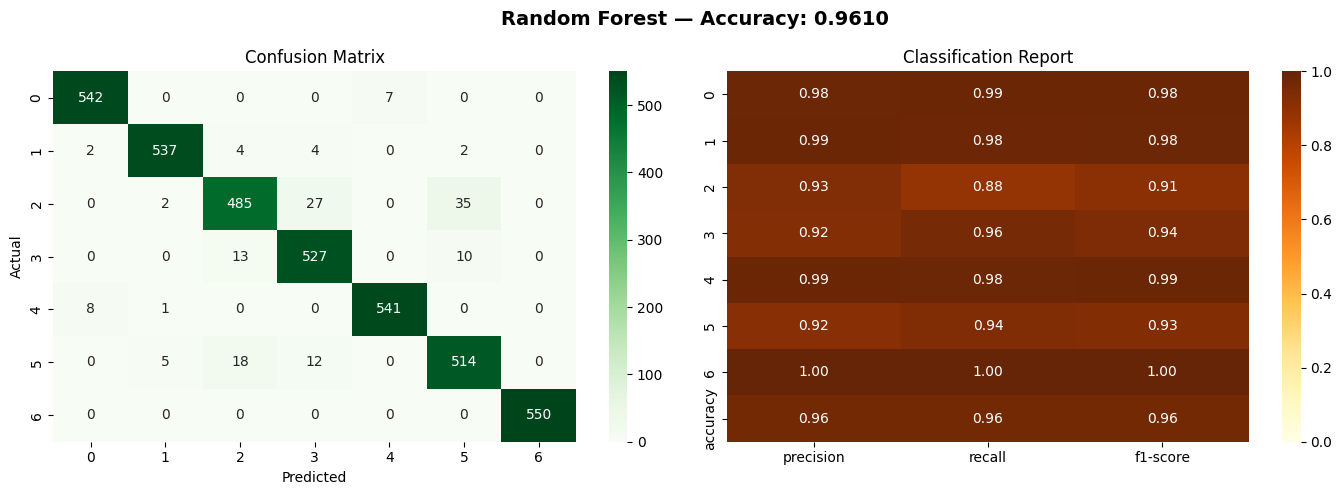

In [12]:
rf_clf = joblib.load('../models/RandomForest_NearMiss_equal_model.pkl')
y_pred = rf_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Random Forest — Accuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_clf.classes_,
            yticklabels=rf_clf.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Classification Report
import pandas as pd
report = classification_report(y_test, y_pred, target_names=[str(c) for c in rf_clf.classes_], output_dict=True)
report_df = pd.DataFrame(report).T.drop(columns='support').iloc[:-2]
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='YlOrBr',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Classification Report')

plt.tight_layout()
plt.show()

In [13]:
metrics_rf = calculate_metrics(y_pred, y_test, 'Random Forest')
metrics_rf = pd.DataFrame([metrics_rf]).T
metrics_rf.head(10)
metrics_rf.to_csv('../results/model_tests/rf_clf_results.csv')

### Voting Classifier - Hard Voting

Accuracy: 0.9342

Matriz de confusion:


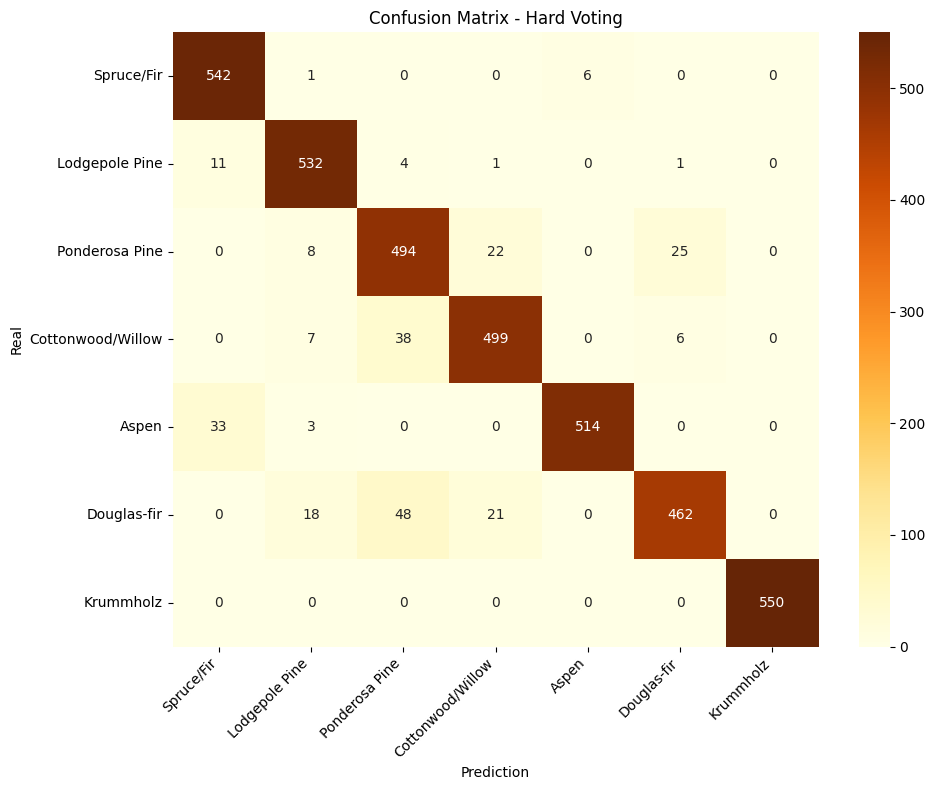

In [14]:
hv_model = joblib.load('../models/Hard-Voting-Clf_NearMiss_equal_model.pkl')
predictions = hv_model.predict(X_test)

y_labels = pd.Series(y_test).map(covertype_class)
pred_labels = pd.Series(predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Hard Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
print('\nClassification report:')
print(classification_report(y_test, predictions))


Classification report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       549
           1       0.93      0.97      0.95       549
           2       0.85      0.90      0.87       549
           3       0.92      0.91      0.91       550
           4       0.99      0.93      0.96       550
           5       0.94      0.84      0.89       549
           6       1.00      1.00      1.00       550

    accuracy                           0.93      3846
   macro avg       0.94      0.93      0.93      3846
weighted avg       0.94      0.93      0.93      3846



In [16]:
metrics_hvc = calculate_metrics(predictions, y_test, 'Hard Voting Classifier')
metrics_hvc = pd.DataFrame([metrics_hvc]).T
metrics_hvc.head(10)
metrics_hvc.to_csv('../results/model_tests/hard_voting_clf.csv')

### Voting Classifier - Soft Voting

Accuracy: 0.9475

Matriz de confusion:


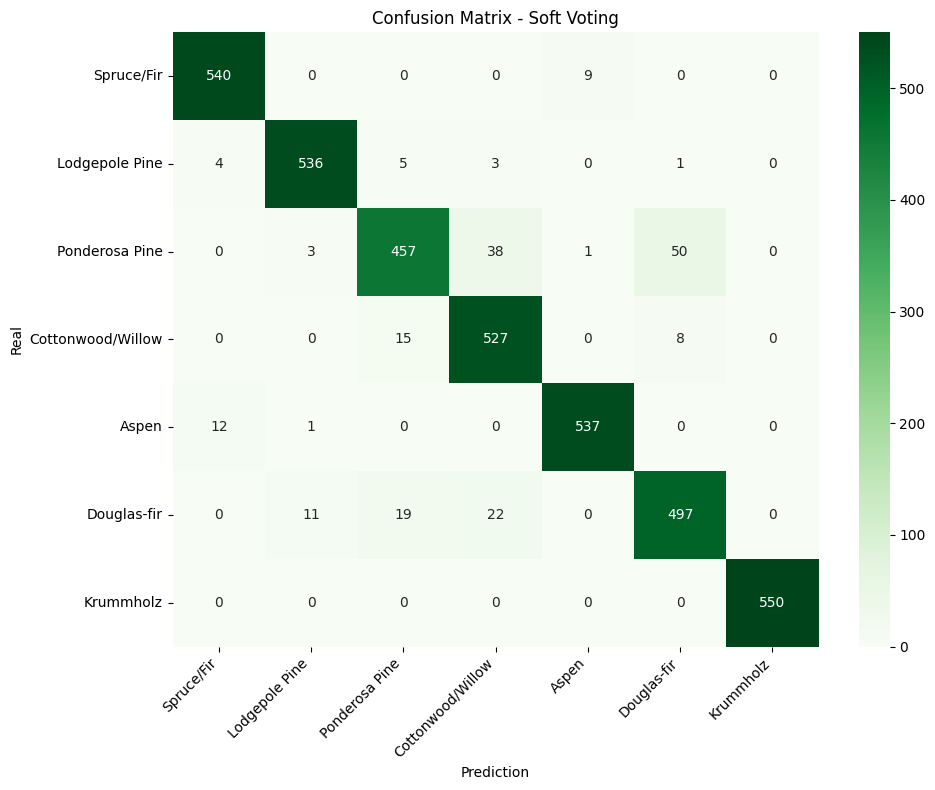

In [17]:
sv_model = joblib.load('../models/Soft-Voting-Clf_NearMiss_equal_model.pkl')
sv_predictions = sv_model.predict(X_test)

sv_pred_labels = pd.Series(sv_predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, sv_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(sv_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, sv_predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
print('\nClassification report:')
print(classification_report(y_test, sv_predictions))


Classification report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       549
           1       0.97      0.98      0.97       549
           2       0.92      0.83      0.87       549
           3       0.89      0.96      0.92       550
           4       0.98      0.98      0.98       550
           5       0.89      0.91      0.90       549
           6       1.00      1.00      1.00       550

    accuracy                           0.95      3846
   macro avg       0.95      0.95      0.95      3846
weighted avg       0.95      0.95      0.95      3846



In [19]:
metrics_svc = calculate_metrics(sv_predictions, y_test, 'Soft Voting Classifier')
metrics_svc = pd.DataFrame([metrics_svc]).T
metrics_svc.head(10)
metrics_svc.to_csv('../results/model_tests/soft_voting_clf_results.csv')

### Bagging

Accuracy: 0.9607

Matriz de confusion:


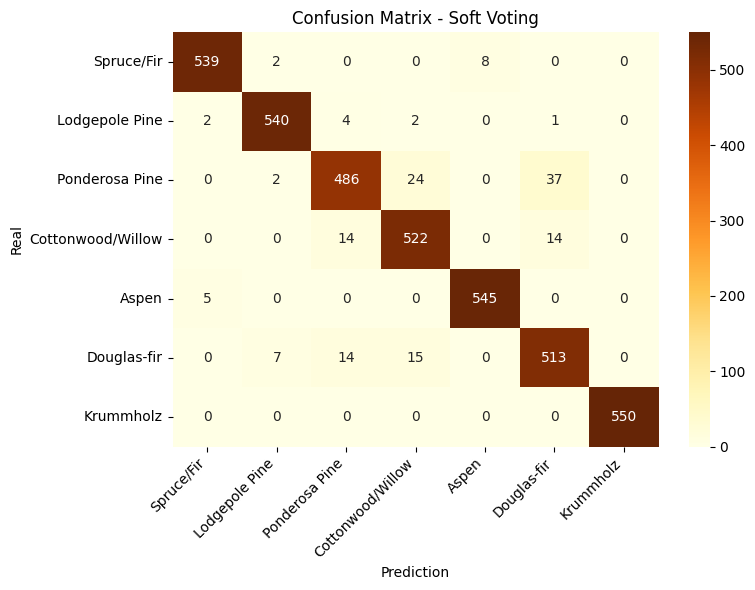

In [20]:
bagging_model = joblib.load('../models/BaggingClassifier_NearMiss_equal_model.pkl')
bagging_predictions = bagging_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, bagging_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(bagging_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, bagging_predictions, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

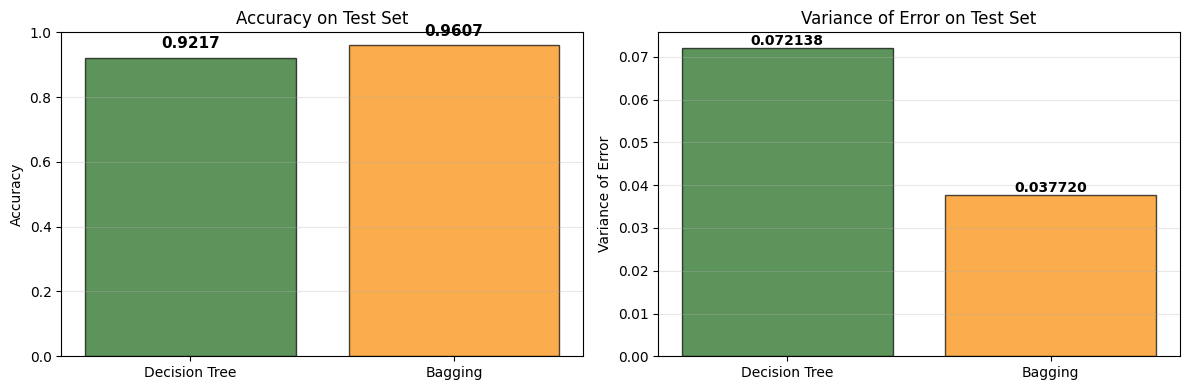

In [21]:
train_df = pd.read_csv('../data/splits/NearMiss_equal_train.csv')
X_train = train_df.drop('Cover_Type', axis=1)
y_train = train_df['Cover_Type']


dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

dt_pred = dt_clf.predict(X_test)

dt_error_samples = (dt_pred != y_test).astype(int)
bagging_error_samples = (bagging_predictions != y_test).astype(int)

# Error variance
dt_error_var = np.var(dt_error_samples)
bagging_error_var = np.var(bagging_error_samples)

# Accuracy
dt_accuracy = round(accuracy_score(y_test, dt_pred), 4)
bagging_accuracy = round(accuracy_score(y_test, bagging_predictions), 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy barplot
models = ['Decision Tree', 'Bagging']
accuracies = [dt_accuracy, bagging_accuracy]
colors = ["#196715", "#FA8900"]
bars = axes[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy on Test Set')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Variance barplot
variances = [dt_error_var, bagging_error_var]
bars = axes[1].bar(models, variances, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Variance of Error')
axes[1].set_title('Variance of Error on Test Set')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, var in zip(bars, variances):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{var:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
metrics_bc = calculate_metrics(bagging_predictions, y_test, 'Bagging Classifier')
metrics_bc = pd.DataFrame([metrics_bc]).T
metrics_bc.head(10)
metrics_bc.to_csv('../results/model_tests/bagging_clf_results.csv')

## Boosting Models
### AdaBoost

Iterations: 200
Minimum error at iteration 155: 0.0387 (accuracy=0.9613)


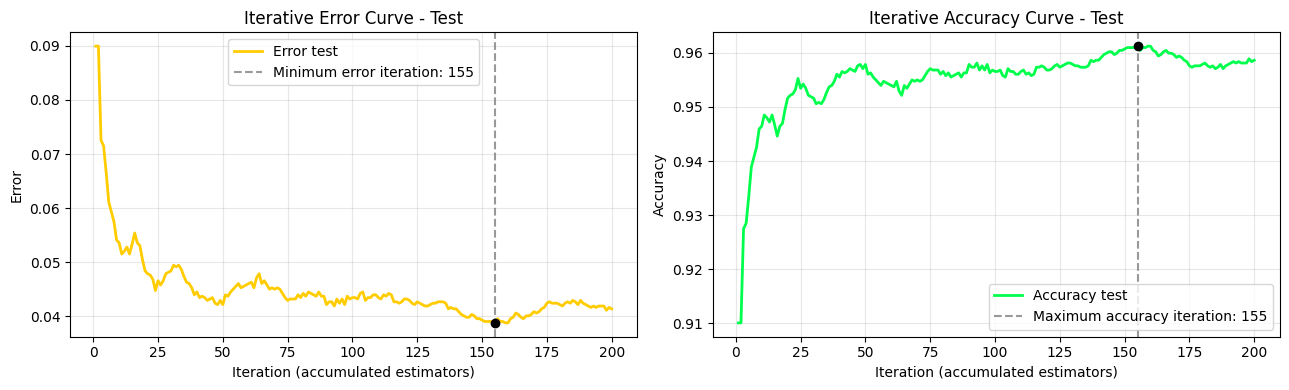

In [23]:
ada_model = joblib.load('../models/AdaBoost-RF_NearMiss_equal_model.pkl')


scaler = ada_model.named_steps.get('scaler', None)
ada_clf = ada_model.named_steps['clf']
X_for_staged = scaler.transform(X_test)

staged_errors = []
staged_accuracies = []

for y_pred_stage in ada_clf.staged_predict(X_for_staged):
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (accumulated estimators)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (accumulated estimators)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
y_pred = ada_model.predict(X_test)

In [25]:
metrics_ada = calculate_metrics(y_pred, y_test, 'AdaBoost')
metrics_ada = pd.DataFrame([metrics_ada]).T
metrics_ada.head(12)
metrics_ada.to_csv('../results/model_tests/adaboost_clf_results.csv')

### XGBoost

Iterations: 300
Minimum error at iteration 179: 0.0320 (accuracy=0.9680)


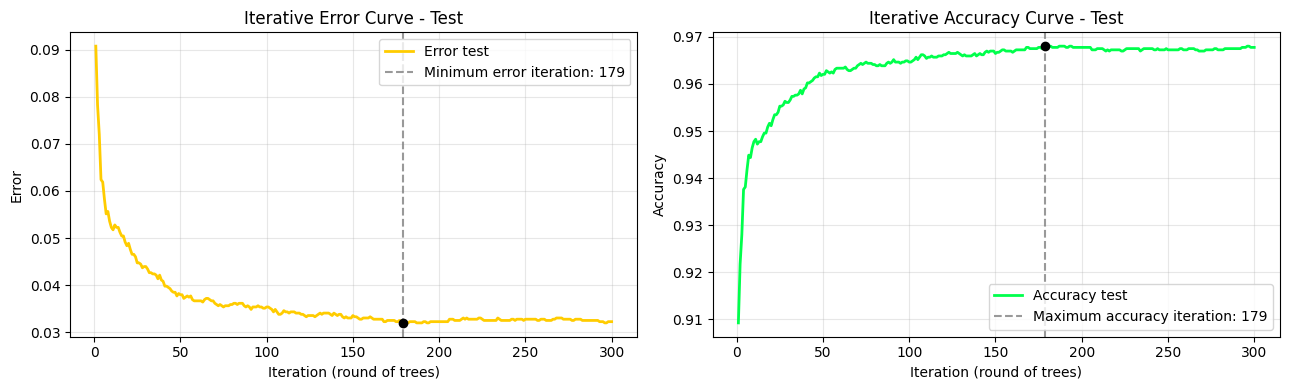

In [26]:
xgb_model = joblib.load('../models/xgboost_NearMiss_equal_model.pkl')

scaler = xgb_model.named_steps.get('scaler', None)
xgb_clf = xgb_model.named_steps['clf']
X_for_staged = scaler.transform(X_test) if scaler is not None else X_test

# Iterative evaluation by number of accumulated trees (iteration_range=(0, i))
n_rounds = xgb_clf.get_booster().num_boosted_rounds()

staged_errors = []
staged_accuracies = []

for i in range(1, n_rounds + 1):
    y_pred_stage = xgb_clf.predict(X_for_staged, iteration_range=(0, i))
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (round of trees)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (round of trees)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
y_pred = xgb_model.predict(X_test)

In [28]:
metrics_xg = calculate_metrics(y_pred, y_test, 'XGBoost')
metrics_xg = pd.DataFrame([metrics_xg])
metrics_xg.T.head(12)
metrics_xg.T.to_csv('../results/model_tests/xgboost_clf_results.csv')

### Stacking

Accuracy: 0.9605


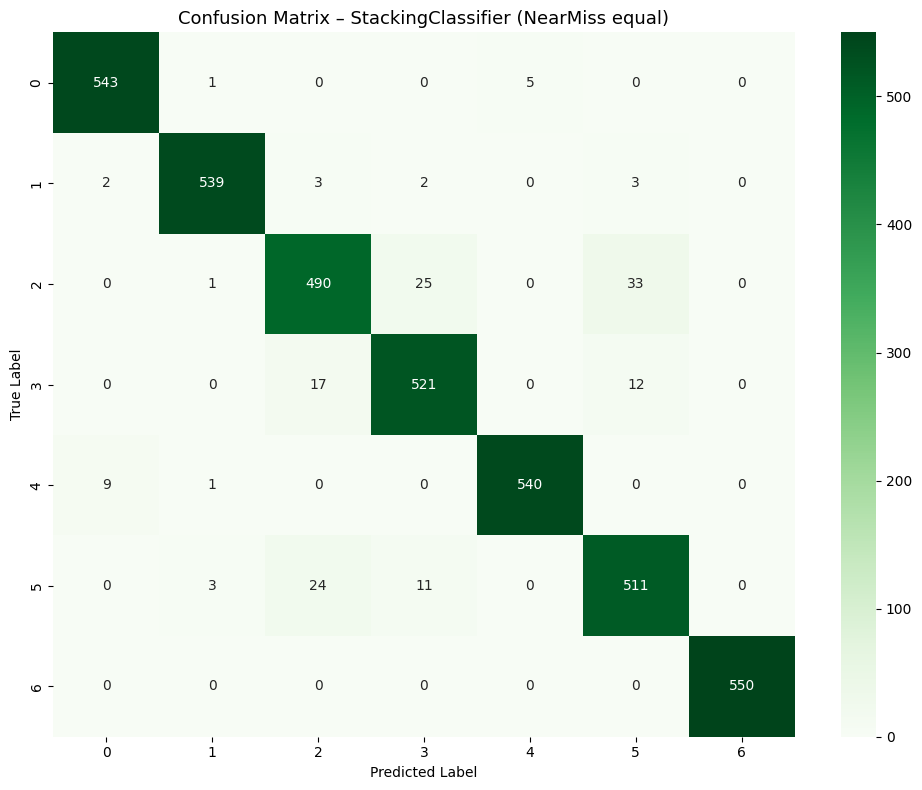

In [29]:
stacking_model = joblib.load('../models/StackingClassifier_NearMiss_equal_model.pkl')
y_pred = stacking_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap( cm, annot=True, fmt='d', cmap='Greens', xticklabels=stacking_model.classes_,
            yticklabels=stacking_model.classes_, ax=ax)
ax.set_title('Confusion Matrix – StackingClassifier (NearMiss equal)', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [30]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       549
           1       0.99      0.98      0.99       549
           2       0.92      0.89      0.90       549
           3       0.93      0.95      0.94       550
           4       0.99      0.98      0.99       550
           5       0.91      0.93      0.92       549
           6       1.00      1.00      1.00       550

    accuracy                           0.96      3846
   macro avg       0.96      0.96      0.96      3846
weighted avg       0.96      0.96      0.96      3846



In [31]:
metrics_sc = calculate_metrics(y_pred, y_test, 'Stacking Classifier')
metrics_sc = pd.DataFrame([metrics_sc]).T
metrics_sc.head(12)
metrics_sc.to_csv('../results/model_tests/stacking_clf_results.csv')

## Model Comparison

In [32]:
from pathlib import Path

In [33]:
metrics_files = {
    "Random Forest": "../results/model_tests/rf_clf_results.csv",
    "Hard Voting": "../results/model_tests/hard_voting_clf.csv",
    "Soft Voting": "../results/model_tests/soft_voting_clf_results.csv",
    "Bagging": "../results/model_tests/bagging_clf_results.csv",
    "AdaBoost": "../results/model_tests/adaboost_clf_results.csv",
    "XGBoost": "../results/model_tests/xgboost_clf_results.csv",
    "Stacking": "../results/model_tests/stacking_clf_results.csv",
}

In [34]:
rows = []
for model_name, file_path in metrics_files.items():
    p = Path(file_path)
    if not p.exists():
        print(f"No existe: {file_path}")
        continue

    s = pd.read_csv(p, index_col=0).iloc[:, 0]
    s.name = model_name
    rows.append(s)

metrics_df = pd.DataFrame(rows)
metrics_df.index.name = "model"

In [35]:
metrics_focus = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mcc",
    "cohen_kappa",
]

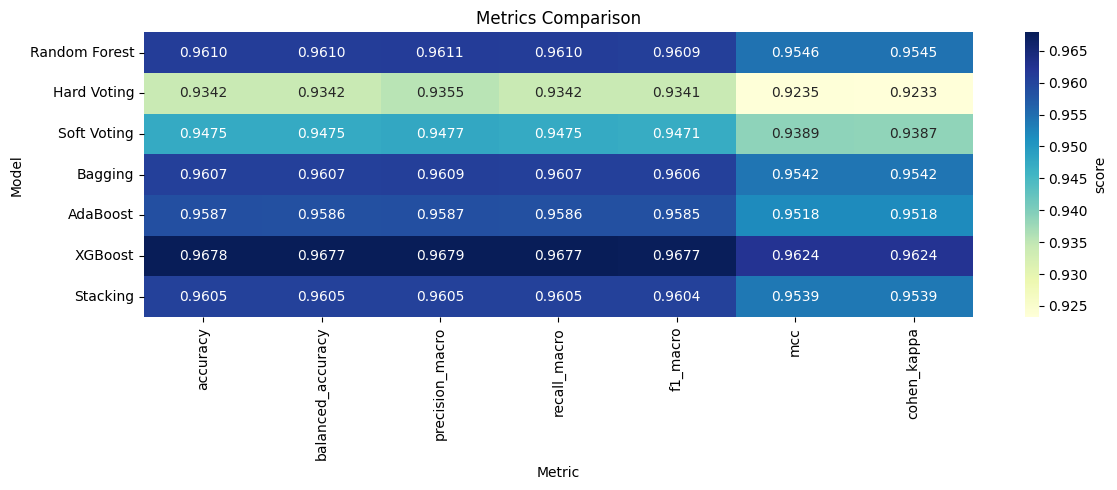

In [36]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    metrics_df[metrics_focus],
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"label": "score"}
)
plt.title("Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


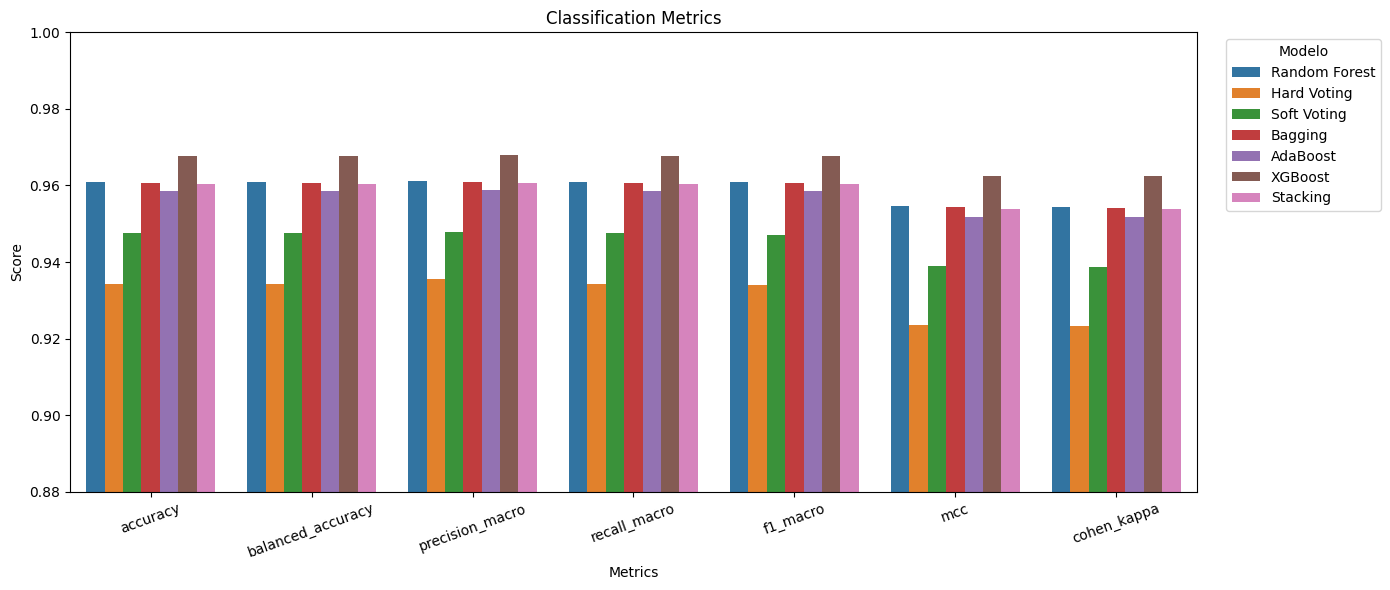

In [37]:
long_df = (
    metrics_df[metrics_focus]
    .reset_index()
    .melt(id_vars="model", var_name="metric", value_name="score")
)

plt.figure(figsize=(14, 6))
sns.barplot(data=long_df, x="metric", y="score", hue="model")
plt.title("Classification Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0.88, 1.0)  # ajusta si quieres ver todo el rango
plt.xticks(rotation=20)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

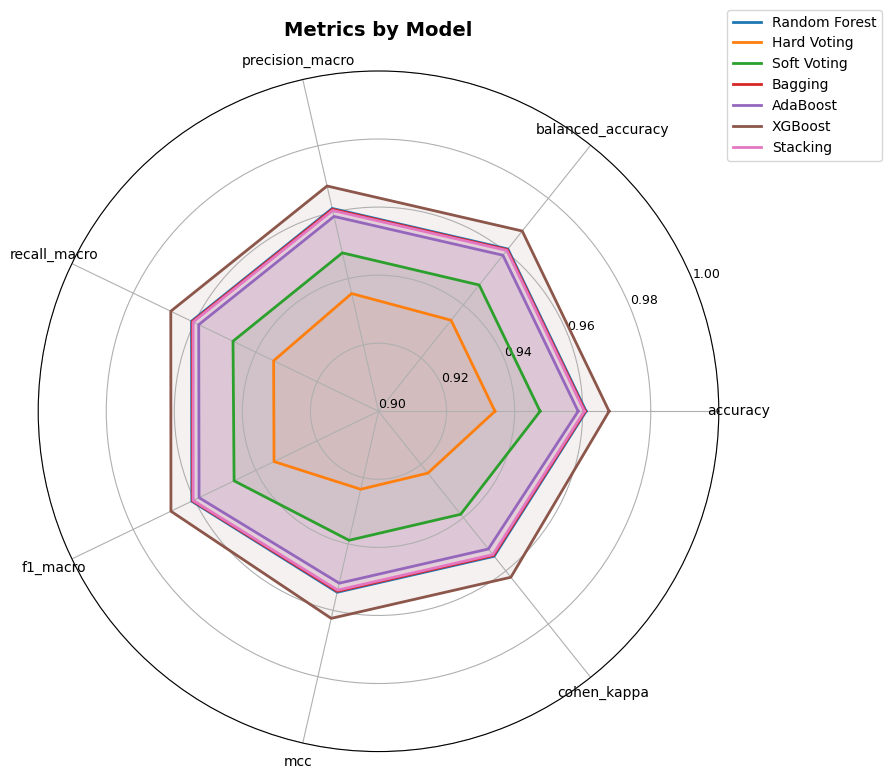

In [38]:
# Metricas que se mostraran en el radar
radar_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mcc",
    "cohen_kappa",
]

# Filtrar solo metricas disponibles
radar_metrics = [m for m in radar_metrics if m in metrics_df.columns]
radar_data = metrics_df[radar_metrics].copy()

# Angulos para cada eje del radar
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})

for model_name, row in radar_data.iterrows():
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0.90, 1.00)
ax.set_yticks([0.90, 0.92, 0.94, 0.96, 0.98, 1.00])
ax.set_yticklabels(["0.90", "0.92", "0.94", "0.96", "0.98", "1.00"], fontsize=9)
ax.set_title("Metrics by Model", pad=25, fontsize=14, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.show()

In [39]:
processed_data = pd.read_parquet('../data/processed/processed_data.parquet')

selected_features = ['Elevation', 'Horizontal_Distance_To_Hydrology', 
                    'Horizontal_Distance_To_Roadways', 'Hillshade_Noon',
                    'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
                    'Wilderness_Area3', 'Wilderness_Area4', 
                    'Soil_Type2', 'Soil_Type4', 'Soil_Type10', 'Soil_Type12',
                    'Soil_Type22', 'Soil_Type23', 'Soil_Type38', 'Soil_Type39',
                    'Euclidean_Distance_To_Hydrology', 'Distance_To_Hydrology_To_Roadways_Ratio',
                    'Total_Distance', 'Aspect_North_South', 'Cover_Type'] 

processed_data = processed_data[selected_features]
processed_data.replace([float('inf'), float('-inf')], pd.NA, inplace=True)
processed_data = processed_data.dropna()

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = processed_data.drop('Cover_Type', axis=1)
y = processed_data['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42)

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
y_pred = rf_clf.predict(X_test)
print(classification_report(y_pred, y_test))

c:\Users\eguil\miniconda3\envs\AML\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           1       0.50      0.41      0.45     65294
           2       0.00      0.00      0.00        40
           3       0.59      0.58      0.58      9084
           4       0.00      0.00      0.00         0
           5       0.59      0.02      0.04     70804
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.23    145222
   macro avg       0.24      0.14      0.15    145222
weighted avg       0.55      0.23      0.26    145222



c:\Users\eguil\miniconda3\envs\AML\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eguil\miniconda3\envs\AML\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eguil\miniconda3\envs\AML\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Users\eguil\AppData\Local\Temp\ipykernel_47844\960137580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=dist.index, y=dist.values, palette="YlGnBu")


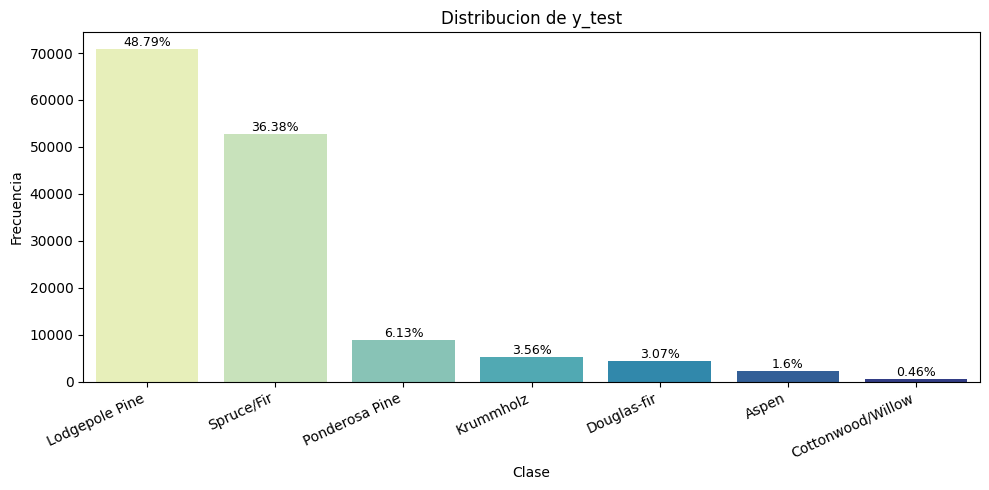

In [44]:
# Si quieres ver nombres en vez de codigos 1..7
y_test_labels = y_test.map(covertype_class)

dist = y_test_labels.value_counts().sort_values(ascending=False)
pct = (dist / dist.sum() * 100).round(2)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=dist.index, y=dist.values, palette="YlGnBu")
plt.title("Distribucion de y_test")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=25, ha="right")

# Etiquetas de porcentaje sobre cada barra
for i, v in enumerate(dist.values):
    ax.text(i, v, f"{pct.iloc[i]}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Testing (Second Stage)

In this section we test the models correctly using the test split we saved at the start of the project. In this case, results are much worse and these results are the ones that correctly asses the performance of the models.

In [12]:
TEST_DATA_DIR = '../data/splits/test_final.parquet'
test_df = pd.read_parquet(TEST_DATA_DIR)
selected_features = [
                    'Elevation', 'Aspect', 'Horizontal_Distance_To_Hydrology',
                    'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am',
                    'Hillshade_Noon', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 
                    'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type2', 'Soil_Type4', 'Soil_Type10', 
                    'Soil_Type12', 'Soil_Type22', 'Soil_Type23', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 
                    'Euclidean_Distance_To_Hydrology', 'Distance_To_Hydrology_To_Roadways_Ratio', 'Distance_To_Fire_To_Hydrology_Ratio', 
                    'Total_Distance', 'Hydrology_Slope', 'Aspect_North_South', 'Cover_Type'
                    ] 
test_df = test_df[selected_features]

test_df.head(5)

,Elevation,Aspect,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Horizontal_Distance_To_Fire_Points,Wilderness_Area1,Wilderness_Area2,...,Soil_Type38,Soil_Type39,Soil_Type40,Euclidean_Distance_To_Hydrology,Distance_To_Hydrology_To_Roadways_Ratio,Distance_To_Fire_To_Hydrology_Ratio,Total_Distance,Hydrology_Slope,Aspect_North_South,Cover_Type
0,1.289744,-0.641465,-0.795492,-0.968032,1.780580,1.614598,-1.842942,-1.092582,1.108321,-0.232715,...,6.026368,-0.1563,-0.124311,-0.814507,1.015416,-0.187721,0.861293,-1.482211,-0.102448,1
1,1.129217,0.662594,-0.522237,-0.446862,0.680171,-0.320374,1.419878,-0.397501,-0.902265,-0.232715,...,-0.165937,-0.1563,-0.124311,-0.539853,1.039737,-0.176184,0.247409,-0.265964,-1.186379,1
2,0.420317,1.412875,1.293877,0.240835,-0.514095,-2.212003,-1.235914,-0.774507,-0.902265,-0.232715,...,-0.165937,-0.1563,-0.124311,1.263611,1.425262,-0.196529,-0.664056,-0.402335,0.753494,2
3,-1.426686,-0.659329,-0.542578,-0.140442,-0.327344,1.117333,-0.542170,-0.228264,-0.902265,-0.232715,...,-0.165937,-0.1563,-0.124311,-0.538659,1.079183,-0.171847,-0.390833,0.626838,-0.052199,2
4,-0.462638,-0.730785,0.396293,0.160165,-1.027779,0.774743,-0.231298,0.544637,-0.902265,-0.232715,...,-0.165937,-0.1563,-0.124311,0.381166,1.373626,-0.181565,-0.166424,0.032566,0.145733,2


In [13]:
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

X_test = test_df.drop('Cover_Type', axis=1)
y_test = test_df['Cover_Type']

mapped_y = y_test.map(covertype_class)
print(mapped_y.value_counts())

Cover_Type
Lodgepole Pine       56651
Spruce/Fir           42367
Ponderosa Pine        7142
Krummholz             4102
Douglas-fir           3468
Aspen                 1899
Cottonwood/Willow      549
Name: count, dtype: int64


### Random Forest

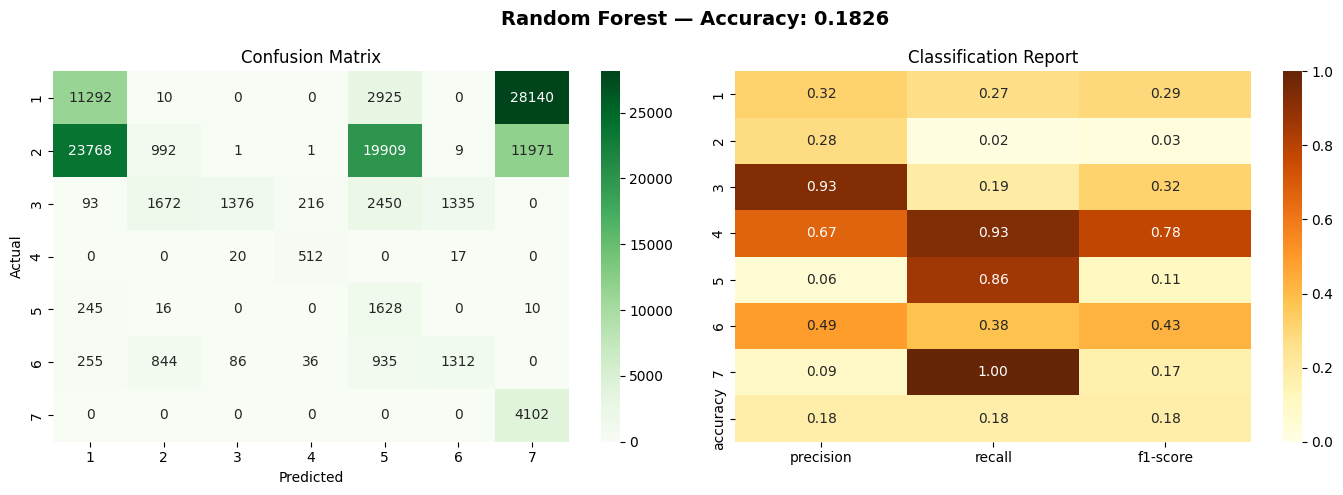

In [20]:
rf_clf = joblib.load('../models/RandomForest_NearMiss_equal_model.pkl')
y_pred = rf_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Random Forest — Accuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_clf.classes_,
            yticklabels=rf_clf.classes_,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Classification Report
import pandas as pd
report = classification_report(y_test, y_pred, target_names=[str(c) for c in rf_clf.classes_], output_dict=True)
report_df = pd.DataFrame(report).T.drop(columns='support').iloc[:-2]
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='YlOrBr',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Classification Report')

plt.tight_layout()
plt.show()

In [21]:
metrics_rf = calculate_metrics(y_pred, y_test, 'Random Forest')
metrics_rf = pd.DataFrame([metrics_rf]).T
metrics_rf.head(10)
metrics_rf.to_csv('../results/model_tests/rf_clf_results.csv')

### Voting Classifier - Hard Voting

Accuracy: 0.2243

Matriz de confusion:


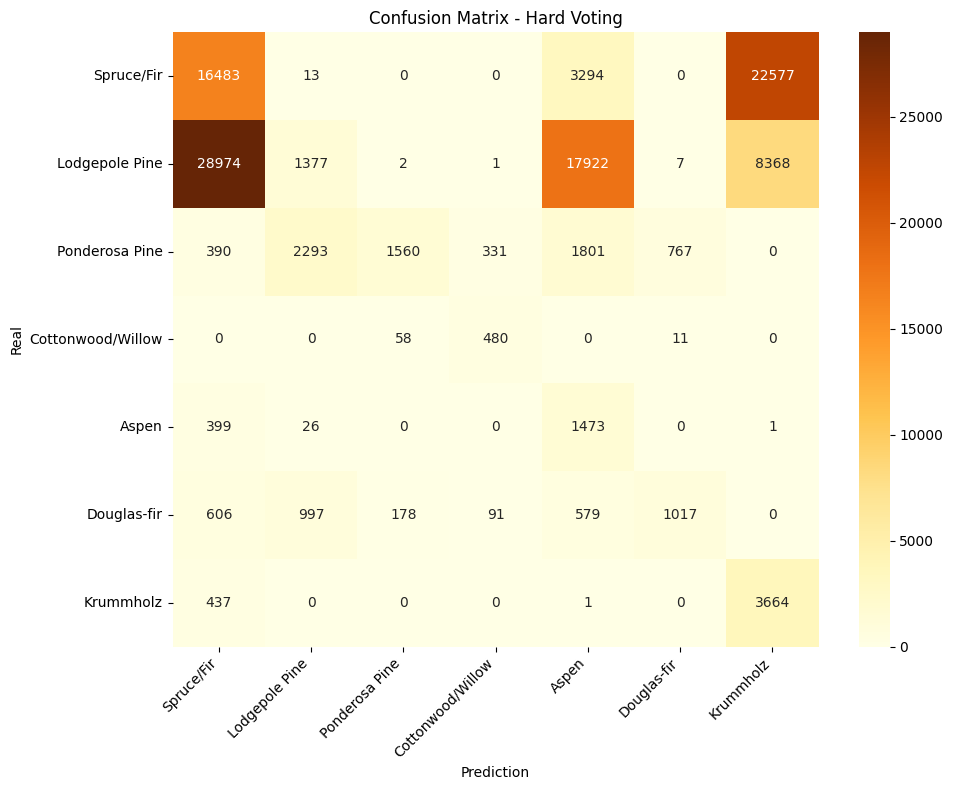

In [22]:
hv_model = joblib.load('../models/Hard-Voting-Clf_NearMiss_equal_model.pkl')
predictions = hv_model.predict(X_test)

y_labels = pd.Series(y_test).map(covertype_class)
pred_labels = pd.Series(predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Hard Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
metrics_hvc = calculate_metrics(predictions, y_test, 'Hard Voting Classifier')
metrics_hvc = pd.DataFrame([metrics_hvc]).T
metrics_hvc.head(10)
metrics_hvc.to_csv('../results/model_tests/hard_voting_clf.csv')

### Voting Classifier - Soft Voting

Accuracy: 0.2055

Matriz de confusion:


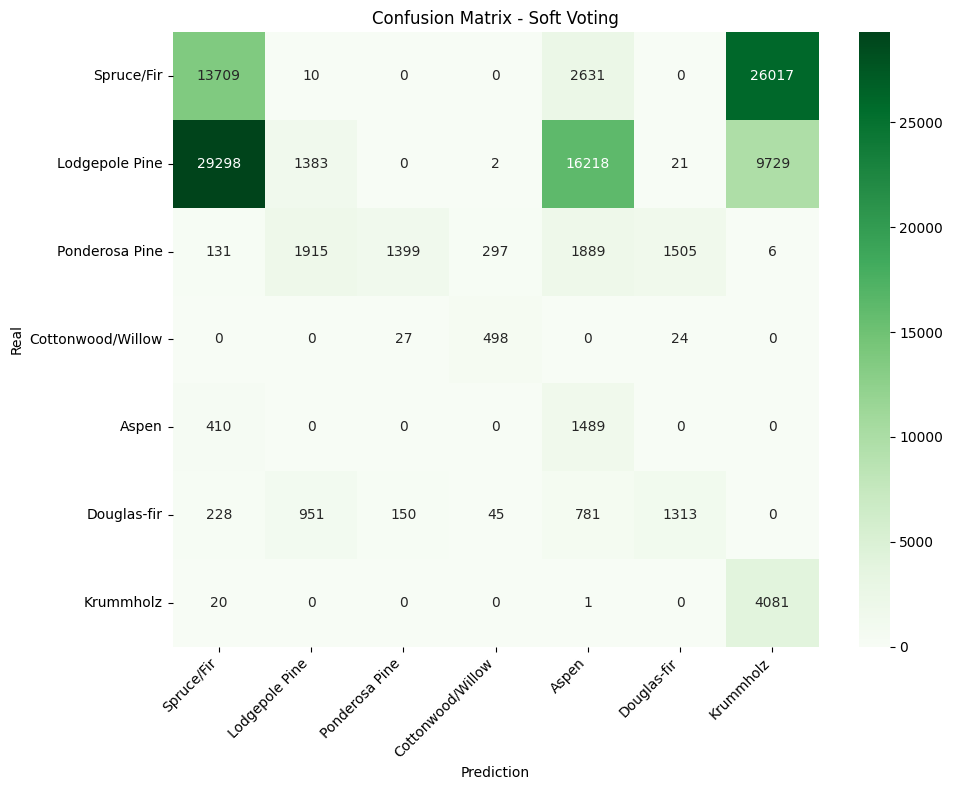

In [17]:
sv_model = joblib.load('../models/Soft-Voting-Clf_NearMiss_equal_model.pkl')
sv_predictions = sv_model.predict(X_test)

sv_pred_labels = pd.Series(sv_predictions).map(covertype_class)

print('Accuracy:', round(accuracy_score(y_test, sv_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(sv_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, sv_predictions, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
metrics_svc = calculate_metrics(sv_predictions, y_test, 'Soft Voting Classifier')
metrics_svc = pd.DataFrame([metrics_svc]).T
metrics_svc.head(10)
metrics_svc.to_csv('../results/model_tests/soft_voting_clf_results.csv')

### AdaBoost

Iterations: 150
Minimum error at iteration 10: 0.7731 (accuracy=0.2269)


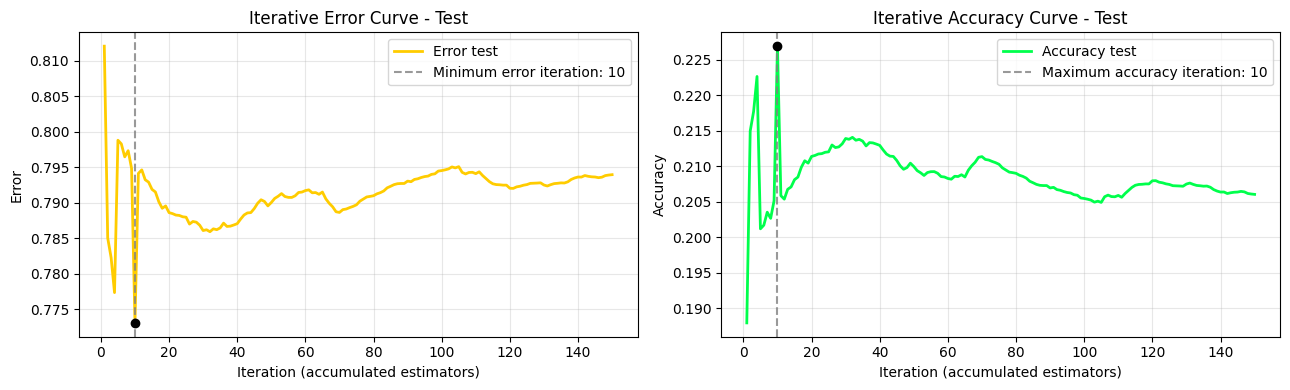

In [40]:
ada_model = joblib.load('../models/AdaBoost-RF_NearMiss_equal_model.pkl')


scaler = ada_model.named_steps.get('scaler', None)
ada_clf = ada_model.named_steps['clf']
X_for_staged = scaler.transform(X_test)

staged_errors = []
staged_accuracies = []

for y_pred_stage in ada_clf.staged_predict(X_for_staged):
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (accumulated estimators)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (accumulated estimators)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [41]:
y_pred = ada_model.predict(X_test)
metrics_ada = calculate_metrics(y_pred, y_test, 'AdaBoost')
metrics_ada = pd.DataFrame([metrics_ada]).T
metrics_ada.head(12)
metrics_ada.to_csv('../results/model_tests/adaboost_clf_results.csv')

### XGBoost

Iterations: 100
Minimum error at iteration 1: 0.9912 (accuracy=0.0088)


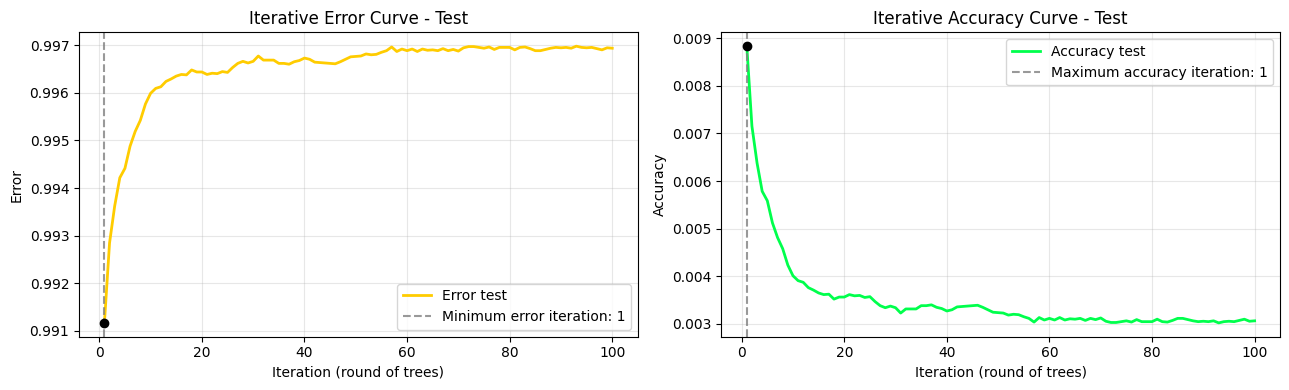

In [14]:
xgb_model = joblib.load('../models/xgboost_NearMiss_equal_model.pkl')

scaler = xgb_model.named_steps.get('scaler', None)
xgb_clf = xgb_model.named_steps['clf']
X_for_staged = scaler.transform(X_test) if scaler is not None else X_test

# Iterative evaluation by number of accumulated trees (iteration_range=(0, i))
n_rounds = xgb_clf.get_booster().num_boosted_rounds()

staged_errors = []
staged_accuracies = []

for i in range(1, n_rounds + 1):
    y_pred_stage = xgb_clf.predict(X_for_staged, iteration_range=(0, i))
    err = np.mean(y_pred_stage != y_test)
    staged_errors.append(err)
    staged_accuracies.append(1 - err)

iterations = np.arange(1, len(staged_errors) + 1)
best_iter = int(np.argmin(staged_errors))
best_error = staged_errors[best_iter]
best_acc = staged_accuracies[best_iter]

print(f'Iterations: {len(staged_errors)}')
print(f'Minimum error at iteration {best_iter + 1}: {best_error:.4f} (accuracy={best_acc:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(iterations, staged_errors, color="#FFCC00", lw=2, label='Error test')
axes[0].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Minimum error iteration: {best_iter + 1}')
axes[0].scatter([best_iter + 1], [best_error], color='black', zorder=5)
axes[0].set_xlabel('Iteration (round of trees)')
axes[0].set_ylabel('Error')
axes[0].set_title('Iterative Error Curve - Test')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(iterations, staged_accuracies, color="#00FF4C", lw=2, label='Accuracy test')
axes[1].axvline(best_iter + 1, color='gray', linestyle='--', alpha=0.8,
                label=f'Maximum accuracy iteration: {best_iter + 1}')
axes[1].scatter([best_iter + 1], [best_acc], color='black', zorder=5)
axes[1].set_xlabel('Iteration (round of trees)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Iterative Accuracy Curve - Test')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
y_pred = xgb_model.predict(X_test)
y_pred = y_pred+1
metrics_xg = calculate_metrics(y_pred, y_test, 'XGBoost')
metrics_xg = pd.DataFrame([metrics_xg])
metrics_xg.T.head(12)
metrics_xg.T.to_csv('../results/model_tests/xgboost_clf_results.csv')

### Stacking Classifier

Accuracy: 0.1857


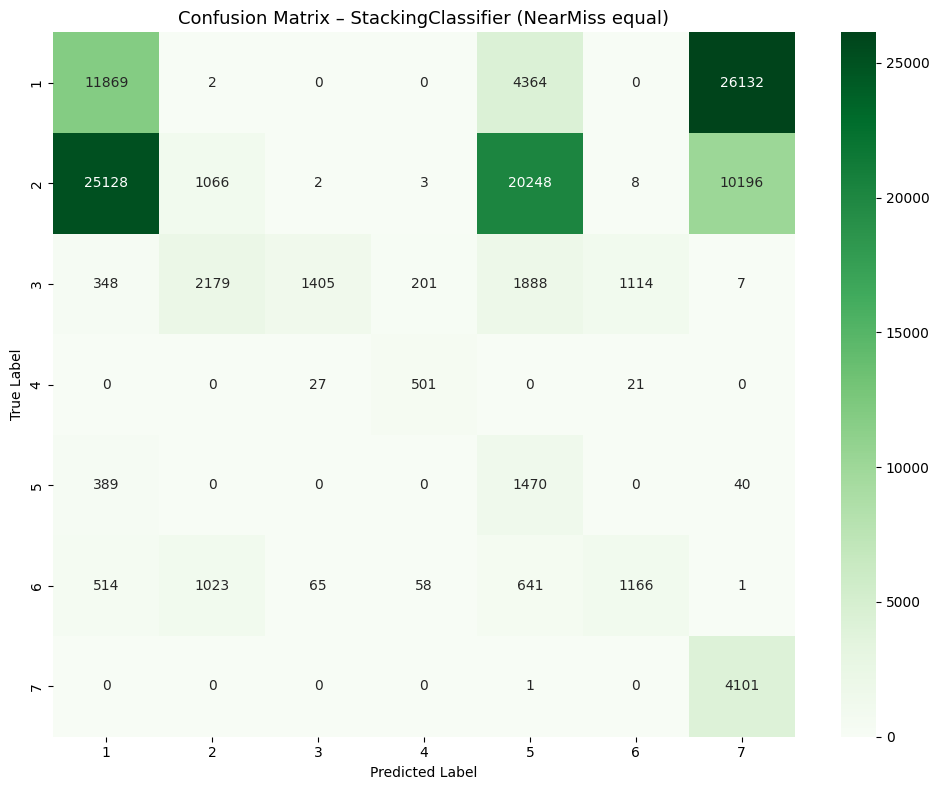

In [5]:
stacking_model = joblib.load('../models/StackingClassifier_NearMiss_equal_model.pkl')
y_pred = stacking_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap( cm, annot=True, fmt='d', cmap='Greens', xticklabels=stacking_model.classes_,
            yticklabels=stacking_model.classes_, ax=ax)
ax.set_title('Confusion Matrix – StackingClassifier (NearMiss equal)', fontsize=13)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

In [8]:
metrics_sc = calculate_metrics(y_pred, y_test, 'Stacking Classifier')
metrics_sc = pd.DataFrame([metrics_sc]).T
metrics_sc.head(12)
metrics_sc.to_csv('../results/model_tests/stacking_clf_results.csv')

### Bagging Classifier

Accuracy: 0.0308

Matriz de confusion:


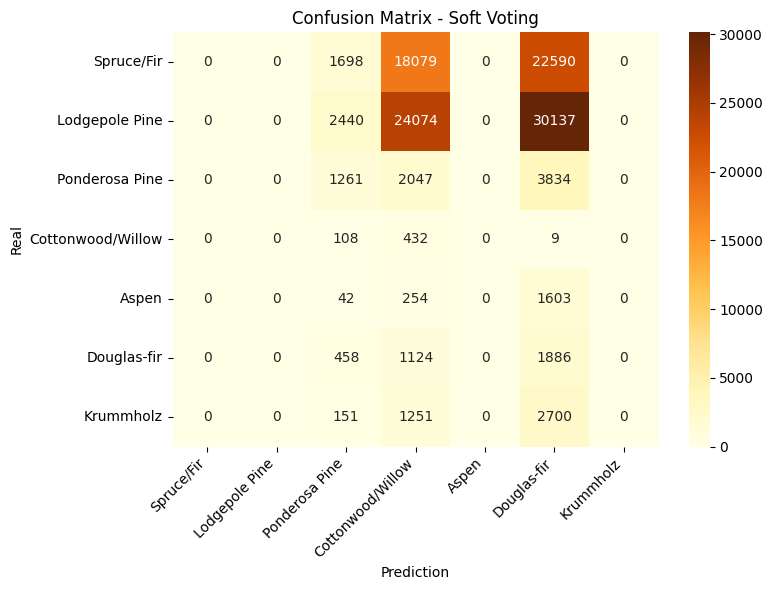

In [25]:
bagging_model = joblib.load('../models/BaggingClassifier_NearMiss_equal_model.pkl')
bagging_predictions = bagging_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, bagging_predictions), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(bagging_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, bagging_predictions, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
metrics_bc = calculate_metrics(bagging_predictions, y_test, 'Bagging Classifier')
metrics_bc = pd.DataFrame([metrics_bc]).T
metrics_bc.head(10)
metrics_bc.to_csv('../results/model_tests/bagging_clf_results.csv')

### Gradient Boosting

Accuracy: 0.0431

Matriz de confusion:


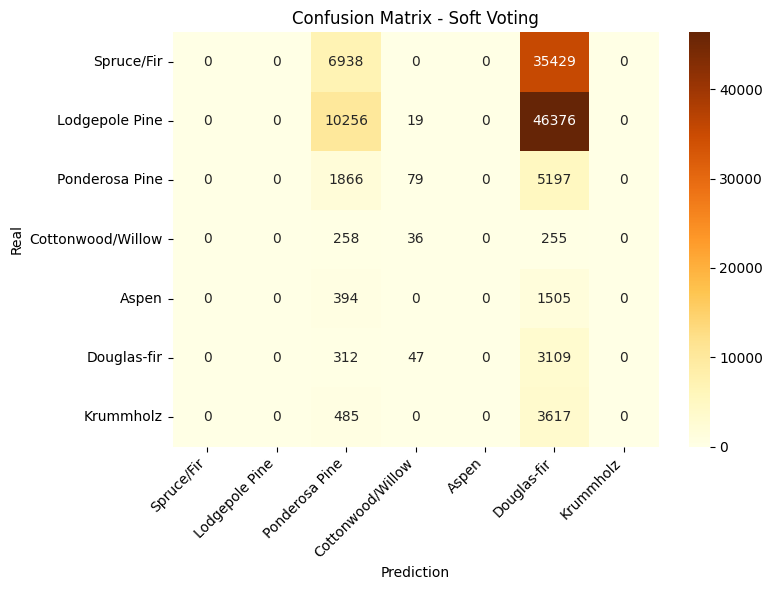

In [30]:
gb_model = joblib.load('../models/GradientBoostingClassifier_NearMiss_equal_model.pkl')
y_pred = gb_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))

print('\nMatriz de confusion:')
classes = sorted(set(pd.Series(y_test).unique()) | set(pd.Series(bagging_predictions).unique()))
is_zero_based = min(classes) == 0 and max(classes) <= 6
label_keys = [int(c) + 1 if is_zero_based else int(c) for c in classes]
class_names = [covertype_class.get(k, str(k)) for k in label_keys]

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Real')
plt.title('Confusion Matrix - Soft Voting')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
metrics_gb = calculate_metrics(y_pred, y_test, 'GradientBoostingClassifier')
metrics_gb = pd.DataFrame([metrics_gb])
metrics_gb.T.to_csv('../results/model_tests/metrics_gb_results.csv')

### Comparison

In [ ]:
metrics_files = {
    "Random Forest": "../results/model_tests/rf_clf_results.csv",
    "Hard Voting": "../results/model_tests/hard_voting_clf.csv",
    "Soft Voting": "../results/model_tests/soft_voting_clf_results.csv",
    "Bagging": "../results/model_tests/bagging_clf_results.csv",
    "AdaBoost": "../results/model_tests/adaboost_clf_results.csv",
    "XGBoost": "../results/model_tests/xgboost_clf_results.csv",
    "Stacking": "../results/model_tests/stacking_clf_results.csv",
    "GradientBoosting": "../results/model_tests/metrics_gb_results.csv"
}

In [43]:
rows = []
for model_name, file_path in metrics_files.items():
    p = Path(file_path)
    if not p.exists():
        print(f"No existe: {file_path}")
        continue

    s = pd.read_csv(p, index_col=0).iloc[:, 0]
    s.name = model_name
    rows.append(s)

metrics_df = pd.DataFrame(rows)
metrics_df.index.name = "model"

In [44]:
metrics_focus = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mcc",
    "cohen_kappa",
]

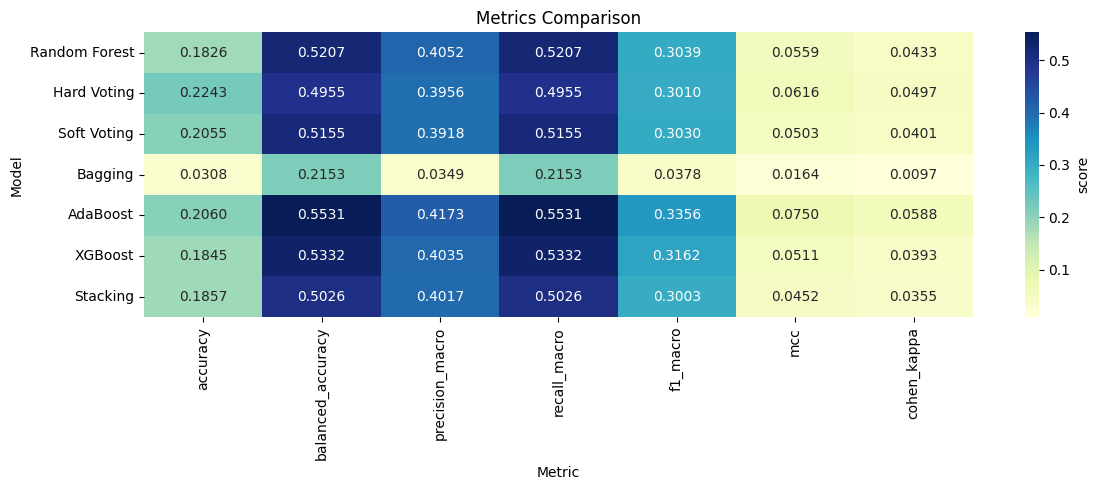

In [45]:
plt.figure(figsize=(12, 5))
sns.heatmap(
    metrics_df[metrics_focus],
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"label": "score"}
)
plt.title("Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

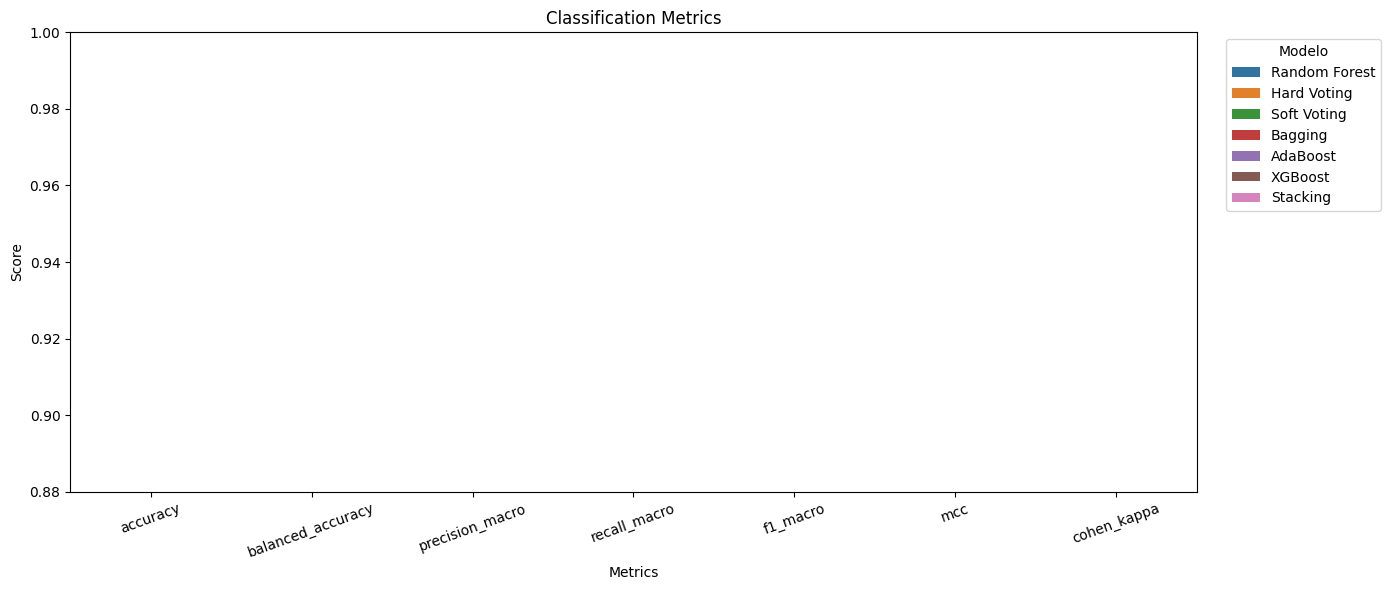

In [46]:
long_df = (
    metrics_df[metrics_focus]
    .reset_index()
    .melt(id_vars="model", var_name="metric", value_name="score")
)

plt.figure(figsize=(14, 6))
sns.barplot(data=long_df, x="metric", y="score", hue="model")
plt.title("Classification Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0.88, 1.0)  
plt.xticks(rotation=20)
plt.legend(title="Modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

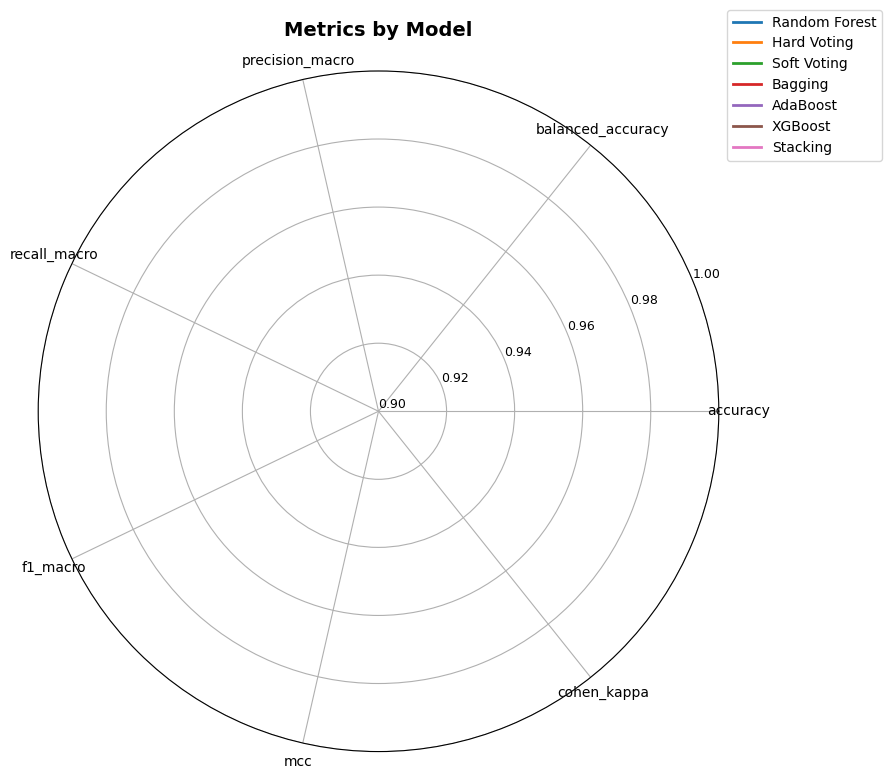

In [47]:

radar_metrics = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "mcc",
    "cohen_kappa",
]

radar_metrics = [m for m in radar_metrics if m in metrics_df.columns]
radar_data = metrics_df[radar_metrics].copy()

# Angulos para cada eje del radar
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})

for model_name, row in radar_data.iterrows():
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0.90, 1.00)
ax.set_yticks([0.90, 0.92, 0.94, 0.96, 0.98, 1.00])
ax.set_yticklabels(["0.90", "0.92", "0.94", "0.96", "0.98", "1.00"], fontsize=9)
ax.set_title("Metrics by Model", pad=25, fontsize=14, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.show()